# Stratus Edge Software, Customer Support Department - Design Process


Business Scenario: Stratus Edge Software, Customer Support Department

Stratus Edge Software is a SaaS company with a global user base. The customer support operations team has been receiving a larger volume of customer support requests that have been documented in long free form text by their team. While these notes contain valuable insight for the company, the data needs to be more organized.

**Goal**: To convert unstructured support notes into structured data and visualizations that enable clearer analysis and more informed business decision-making.


*Packages*

In [ ]:
# Loading Packages and API
import openai
import os
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('openai_api_key')

client = openai.OpenAI()

*Mounting Support Notes*

In [ ]:
# Loading Support Notes Data File
from google.colab import drive
drive.mount('/content/drive')

# Stratus Edge Software Support Notes
support_notes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/support_notes.csv')

support_notes.info()
# support_notes

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   note_id       40 non-null     int64 
 1   support_note  40 non-null     object
dtypes: int64(1), object(1)
memory usage: 772.0+ bytes


# JSON Schema Design


Jamie Ramos, Director of Support Operations and their team would like to know:

*   **Issue Types**: Access problems, system outages, bugs, customer complaints, etc.
*   **Software/Internal Tools**: Reporting, Login, , etc.
*   **Severity Level**: Levels will be assessed on a scale of 1-5, with 5 being severe.
*  **Resolution**: Resolution will be categorized simply as if it was solved, unsolved, escalated or unknown.
*   **Follow-up**: If the support notes indicate that a follow was needed, we will categorize it as Yes or No.

**AI was used to help identify common themes in the raw support notes, and based on those themes, the following structured schema was created for consistent extraction.**

Based on the following requests, the following {Fact Block} was created:


*Fact Block*

In [ ]:
support_notes_facts = support_notes_facts = {
    "CompanyName": "Stratus Edge Software",
    "department": "Customer Support",
    "description": "Stratus Edge Software Customer Support Notes into reporting ",
    "note_id": "integer",
    "issue_type": [
        "access/authentication",
        "performance/latency",
        "system outage",
        "bug/error",
        "billing/payments",
        "reporting/analytics",
        "api/integrations",
        "data/database",
        "customer complaint",
        "other/unclear"
    ],

    "internal_tools": [
        "Dashboard/UI",
        "Reporting",
        "Billing System",
        "API/Integrations",
        "Authentication/Access",
        "Data/Database",
        "Other/Unspecified"
    ],

    "severity_level": "integer from 1 (low) to 5 (critical)",

    "resolution_status": [
        "solved",
        "escalated",
        "unresolved",
        "unknown"
    ],

    "need_follow_up": "boolean"
}


# LLM Implementation


The system message is used to define the role and behavior of the large language model for this task. Rather than functioning as a conversational assistant, the LLM is explicitly instructed to act as a Support Operations Analyst whose responsibility is to extract structured attributes from unstructured customer support notes.

In [ ]:
def support_notes_data():
    return f"""

    You are a Support Operations Analyst for Stratus Edge Software.
Extract structured fields from each support note for dashboarding.

Rules:
- Use ONLY what is stated or strongly implied by the note.
- Do not invent names, dates, or metrics.
- internal_tools can include multiple items if multiple tools/systems are mentioned.
- severity_level: 1=minor annoyance, 3=moderate impact, 5=critical/outage or many users blocked.
- resolution_status:
  - solved: indicates resolved/fixed/closed
  - escalated: mentions escalation/engineering/backline/bug filed/hand-off
  - unresolved: still failing / ongoing / not fixed
  - unknown: not enough info
- need_follow_up is true if next steps are mentioned, waiting on another team/customer, monitoring, or unresolved.

Return ONLY valid JSON that matches this schema:
{json.dumps(support_notes_facts)}"""


A GPT-4.1 nano large language model was selected and the temperature parameter was set to 0 to support consistent and reliable data extraction from unstructured text.


In [ ]:
def get_response_from_messages(messages_input, model_input = "gpt-4.1-nano", temperature_input = 0):
    response = client.responses.create(
        model = model_input,
        input = messages_input,
        temperature = temperature_input,
    )

    response = response.output_text
    return response

In [ ]:
# Function call Python Block Generated by AI

def extract_fields(note_id, note_text):
    messages = [
        {"role": "system", "content": support_notes_data()},
        {"role": "user", "content": f"note_id: {note_id}\nsupport_note: {note_text}"}
    ]

    response_text = get_response_from_messages(messages)


    start = response_text.find("{")
    end = response_text.rfind("}")
    return json.loads(response_text[start:end+1])



In [ ]:
# Printing Data Frame Code Block Generated By AI
results = []

for i in range(len(support_notes)):
    note_id = int(support_notes.loc[i, "note_id"])
    note_text = str(support_notes.loc[i, "support_note"])

    extracted = extract_fields(note_id, note_text)
    results.append(extracted)

structured_df = pd.DataFrame(results)
structured_df.to_csv("structured_support_notes.csv", index=False)
structured_df



,CompanyName,department,description,note_id,issue_type,internal_tools,severity_level,resolution_status,need_follow_up
0,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,1,[access/authentication],[Authentication/Access],3,solved,False
1,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,2,[performance/latency],[Dashboard/UI],3,solved,False
2,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,3,[billing/payments],"[Reporting, Billing System]",3,solved,False
3,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,4,[api/integrations],[API/Integrations],3,unresolved,True
4,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,5,[reporting/analytics],[Reporting],3,solved,False
5,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,6,[access/authentication],[Authentication/Access],3,escalated,False
6,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,7,[data/database],"[Dashboard/UI, Reporting]",3,unresolved,True
7,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,8,[reporting/analytics],"[Reporting, API/Integrations]",3,escalated,True
8,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,9,[access/authentication],[Authentication/Access],3,solved,False
9,Stratus Edge Software,Customer Support,Stratus Edge Software Customer Support Notes i...,10,[system outage],[Billing System],5,escalated,False


#Visualizations

With the data extraction tool in place, the structured output can now be analyzed to answer key business questions about customer support trends and performance.

In [ ]:
import matplotlib.pyplot as plt

# The following code blocks were generated with the assistance of AI:

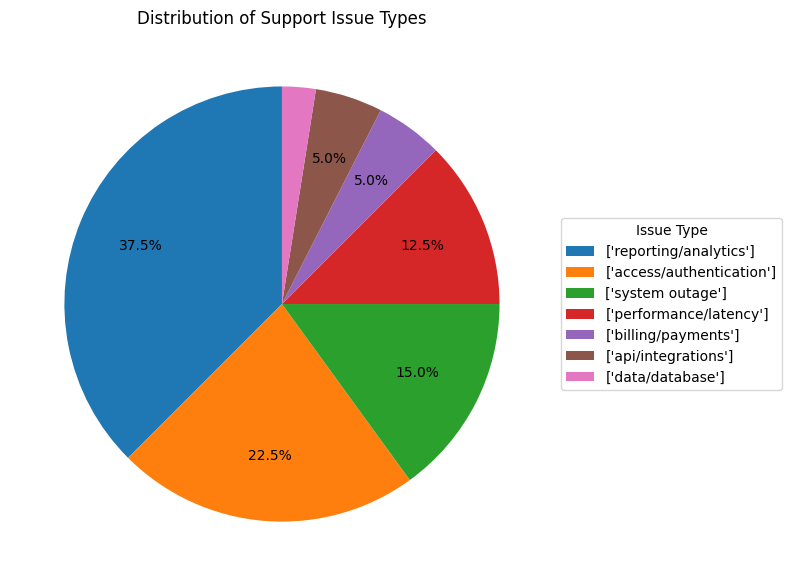

In [ ]:
# Business Question #1
# Issue Type - What types of issues are customers contacting support about most frequently?


issue_counts = structured_df["issue_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    issue_counts,
    autopct=lambda p: f"{p:.1f}%" if p >= 5 else "",  # hide tiny slices
    startangle=90,
    pctdistance=0.7  # pulls percentages inward
)

ax.set_title("Distribution of Support Issue Types")

ax.legend(
    wedges,
    issue_counts.index,
    title="Issue Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.savefig("issue_types_pie.png", dpi=200, bbox_inches="tight")
plt.show()


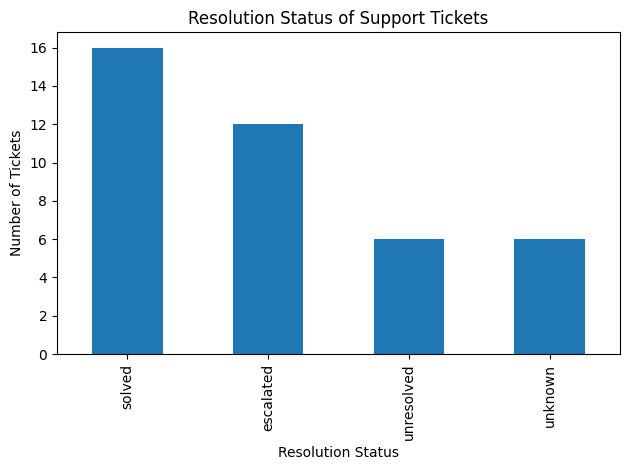

In [ ]:
# Business Question #2
# Resolution - Are support issues being resolved efficiently, or do they frequently remain unresolved or escalated?

structured_df["resolution_status"].value_counts().plot(kind="bar")

plt.title("Resolution Status of Support Tickets")
plt.xlabel("Resolution Status")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()


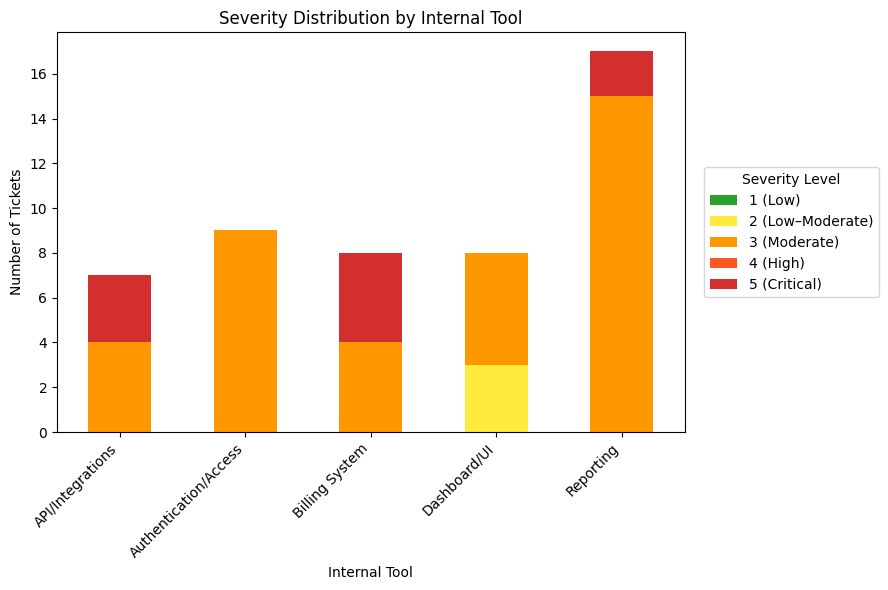

In [ ]:
# Business Question #3

# Severity Distribution - Which internal systems or tools are associated with the most severe support issues?

# Explode internal_tools in case some tickets reference multiple tools
exploded_df = structured_df.explode("internal_tools")

# Crosstab: Internal Tool vs Severity Level
severity_ct = pd.crosstab(
    exploded_df["internal_tools"],
    exploded_df["severity_level"]
).reindex(columns=[1, 2, 3, 4, 5])

# Intuitive severity color mapping
severity_colors = {
    1: "#2ca02c",  # green (low)
    2: "#ffeb3b",  # yellow (low–moderate)
    3: "#ff9800",  # orange (moderate)
    4: "#ff5722",  # orange-red (high)
    5: "#d32f2f"   # red (critical)
}

# Plot
ax = severity_ct.plot(
    kind="bar",
    stacked=True,
    color=[severity_colors[c] for c in severity_ct.columns],
    figsize=(9, 6)
)

ax.set_title("Severity Distribution by Internal Tool")
ax.set_xlabel("Internal Tool")
ax.set_ylabel("Number of Tickets")

# Legend outside the chart
ax.legend(
    title="Severity Level",
    labels=[
        "1 (Low)",
        "2 (Low–Moderate)",
        "3 (Moderate)",
        "4 (High)",
        "5 (Critical)"
    ],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("severity_by_internal_tool.png", dpi=200, bbox_inches="tight")
plt.show()

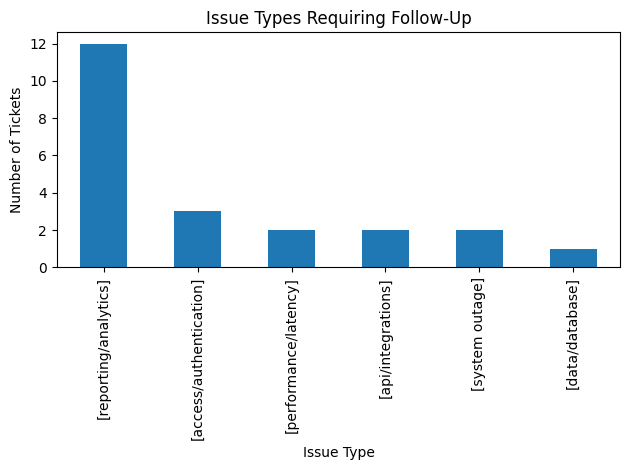

In [ ]:
# Business Question #4
# Which types of issues are most likely to require follow-up?

followup_df = structured_df[structured_df["need_follow_up"] == True]

followup_df["issue_type"].value_counts().plot(kind="bar")

plt.title("Issue Types Requiring Follow-Up")
plt.xlabel("Issue Type")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()